# MedSAM Baseline Test - Medical Image Segmentation Evaluation

This notebook provides comprehensive baseline evaluation of Medical SAM (MedSAM) on multiple medical image segmentation datasets including:
- 🧠 **MRI**: Hippocampus segmentation (brain structures)
- 🫁 **CT**: Spleen segmentation (abdominal organ)  
- 🔬 **Ultrasound**: Breast tumor segmentation

**Prerequisites:**
- RL-CC-SAM environment activated with 'llms' virtual environment
- Required dependencies from requirements.txt
- GPU runtime recommended (Runtime > Change runtime type > GPU)

**References:**
- MedSAM paper: https://arxiv.org/abs/2304.12306
- Original SAM: segment-anything/README.md
- Medical Decathlon datasets: http://medicaldecathlon.com/

**Estimated Runtime:** 45-90 minutes (depending on dataset size and hardware)

## 🔧 1. Environment Setup and Configuration

Following the established patterns from setup_colab.ipynb and compliance with .cursor/rules

In [1]:
# Environment setup and Colab detection
# Ref: setup_colab.ipynb for Colab integration patterns
import sys
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Running in Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')

    # Set up paths for Colab - following setup_colab.ipynb patterns
    DRIVE_ROOT = '/content/drive/MyDrive'
    PROJECT_ROOT = f'{DRIVE_ROOT}/RL-CC-SAM'

    # Change to project directory
    os.chdir(PROJECT_ROOT)
    sys.path.append(PROJECT_ROOT)

    print(f"📁 Working directory: {os.getcwd()}")
else:
    print("💻 Running locally")
    # Assume notebook is in notebooks/ folder
    PROJECT_ROOT = Path.cwd().parent
    os.chdir(PROJECT_ROOT)

    print(f"📁 Working directory: {PROJECT_ROOT}")

# Set up directories following project structure
DATASETS_DIR = Path(PROJECT_ROOT) / "datasets"
PRETRAINED_DIR = Path(PROJECT_ROOT) / "pretrained"
SEGMENT_ANYTHING_DIR = Path(PROJECT_ROOT) / "segment-anything"

# Create directories
for dir_path in [DATASETS_DIR, PRETRAINED_DIR]:
    dir_path.mkdir(exist_ok=True)

print(f"📊 Datasets directory: {DATASETS_DIR}")
print(f"🧠 Pretrained models directory: {PRETRAINED_DIR}")
print(f"🔧 Segment Anything submodule: {SEGMENT_ANYTHING_DIR}")

# Verify submodules are available (following .cursor/rules/submodule-handling.mdc)
if not SEGMENT_ANYTHING_DIR.exists():
    print("❌ Segment Anything submodule not found!")
    print("💡 Run: git submodule update --init --recursive")
    print("💡 Or use setup_colab.ipynb for initial setup")
else:
    print("✅ Segment Anything submodule found")

print("✅ Environment setup complete")


🌐 Running in Google Colab
Mounted at /content/drive
📁 Working directory: /content/drive/MyDrive/RL-CC-SAM
📊 Datasets directory: /content/drive/MyDrive/RL-CC-SAM/datasets
🧠 Pretrained models directory: /content/drive/MyDrive/RL-CC-SAM/pretrained
🔧 Segment Anything submodule: /content/drive/MyDrive/RL-CC-SAM/segment-anything
✅ Segment Anything submodule found
✅ Environment setup complete


## 📚 2. Library Imports and Dependencies

All dependencies are managed through requirements.txt (following .cursor/rules/python-jupyter.mdc)

In [2]:
# Import essential libraries
# All dependencies should be installed via requirements.txt

# Core libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json
import math
import glob
from tqdm.auto import tqdm

# Medical imaging
import nibabel as nib
from scipy.ndimage import distance_transform_edt

# SAM - using existing submodule (following .cursor/rules/submodule-handling.mdc)
sys.path.insert(0, str(SEGMENT_ANYTHING_DIR))
from segment_anything import sam_model_registry, SamPredictor

# Image processing
from skimage import io, transform
import torch.nn.functional as F

# Device handling following .cursor/rules/pytorch-devices.mdc
def get_device():
    """Get optimal device following PyTorch device handling rules."""
    if torch.backends.mps.is_available():
        return torch.device("mps")  # Apple Silicon
    elif torch.cuda.is_available():
        return torch.device("cuda")  # NVIDIA GPU
    else:
        return torch.device("cpu")   # CPU fallback

device = get_device()
print(f"🚀 Using device: {device}")

# Set style for plots
plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'default')
print("✅ Libraries imported successfully")


🚀 Using device: cuda
✅ Libraries imported successfully


## 🧠 3. MedSAM Model Setup and Loading

Following best practices for model management in the pretrained/ directory

In [3]:
# Load MedSAM model (assumes already downloaded via setup_colab.ipynb)
# Following .cursor/rules: Downloads handled in setup_colab.ipynb

def load_medsam_model():
    """
    Load MedSAM model from pretrained directory.

    Prerequisites:
    - Run setup_colab.ipynb first to download the model
    - Model should be at: pretrained/medsam_vit_b.pth
    """

    model_filename = "medsam_vit_b.pth"
    model_path = PRETRAINED_DIR / model_filename

    # Check if model exists
    if not model_path.exists():
        print(f"❌ MedSAM model not found at: {model_path}")
        print("💡 Please run setup_colab.ipynb first to download the model")
        print("💡 The setup notebook will download all required models and datasets")
        raise FileNotFoundError(f"MedSAM model not found. Run setup_colab.ipynb first.")

    try:
        print(f"🔄 Loading MedSAM model from: {model_path}")

        # Load using SAM architecture with MedSAM weights
        sam_model = sam_model_registry["vit_b"](checkpoint=str(model_path))
        sam_model = sam_model.to(device)
        sam_model.eval()

        # Create predictor
        predictor = SamPredictor(sam_model)

        print(f"✅ MedSAM model loaded successfully")
        print(f"   Model size: {model_path.stat().st_size / (1024**3):.1f} GB")
        print(f"   Model parameters: {sum(p.numel() for p in sam_model.parameters()):,}")
        print(f"   Device: {device}")

        return sam_model, predictor

    except Exception as e:
        print(f"❌ Error loading MedSAM model: {e}")
        print("💡 The model file might be corrupted. Re-run setup_colab.ipynb")
        raise

# Load the MedSAM model
medsam_model, predictor = load_medsam_model()


🔄 Loading MedSAM model from: /content/drive/MyDrive/RL-CC-SAM/pretrained/medsam_vit_b.pth
✅ MedSAM model loaded successfully
   Model size: 0.3 GB
   Model parameters: 93,735,472
   Device: cuda


接下来读取MRI体积数据和对应的标签。在评估中，我们将使用训练集作为测试图像（MedSAM并未在该特定数据上训练过，因此训练集可以用作评估基线）。我们将利用Nibabel库读取NIfTI格式的体数据，并提取其中的2D切片进行推理：

In [18]:
MEDICAL_DECATHLON_DIR = DATASETS_DIR / "medical_decathlon"
Task04_Hippocampus_dir = MEDICAL_DECATHLON_DIR / "Task04_Hippocampus"
Task09_Spleen_dir = MEDICAL_DECATHLON_DIR / "Task09_Spleen"
BUSI_Dataset_dir = DATASETS_DIR / "BUSI_Dataset"

['hippocampus_001.nii.gz\thippocampus_146.nii.gz\thippocampus_276.nii.gz', 'hippocampus_003.nii.gz\thippocampus_148.nii.gz\thippocampus_277.nii.gz', 'hippocampus_004.nii.gz\thippocampus_149.nii.gz\thippocampus_279.nii.gz', 'hippocampus_006.nii.gz\thippocampus_150.nii.gz\thippocampus_280.nii.gz', 'hippocampus_007.nii.gz\thippocampus_152.nii.gz\thippocampus_282.nii.gz', 'hippocampus_008.nii.gz\thippocampus_154.nii.gz\thippocampus_286.nii.gz', 'hippocampus_011.nii.gz\thippocampus_155.nii.gz\thippocampus_287.nii.gz', 'hippocampus_014.nii.gz\thippocampus_156.nii.gz\thippocampus_288.nii.gz', 'hippocampus_015.nii.gz\thippocampus_157.nii.gz\thippocampus_289.nii.gz', 'hippocampus_017.nii.gz\thippocampus_158.nii.gz\thippocampus_290.nii.gz', 'hippocampus_019.nii.gz\thippocampus_160.nii.gz\thippocampus_292.nii.gz', 'hippocampus_020.nii.gz\thippocampus_161.nii.gz\thippocampus_294.nii.gz', 'hippocampus_023.nii.gz\thippocampus_162.nii.gz\thippocampus_295.nii.gz', 'hippocampus_024.nii.gz\thippocampus_

In [35]:
import nibabel as nib
import numpy as np

!pwd
# 获取Hippocampus训练集文件列表
imagesTr = !ls -1 {Task04_Hippocampus_dir}/imagesTr
labelsTr = !ls -1 {Task04_Hippocampus_dir}/labelsTr
image_files = sorted([f for f in imagesTr])
label_files = sorted([f for f in labelsTr])

print(f"共有 {len(image_files)} 副MRI体积用于评估.")

# 准备存储MRI数据集的测试切片和标签
mri_slices = []      # 将保存二维切片图像 (numpy数组)
mri_slice_masks = [] # 将保存对应的二维GT掩码
mri_slice_labels = []# 保存掩码对应的解剖结构标签（1=左海马, 2=右海马）

for img_file, lbl_file in zip(image_files, label_files):
    print(f"img_file:'{img_file}', lbl_file:{lbl_file}")
    img_path = f"{Task04_Hippocampus_dir}/imagesTr/{img_file}"
    lbl_path = f"{Task04_Hippocampus_dir}/labelsTr/{lbl_file}"
    # 载入NIfTI体数据
    img_nii = nib.load(img_path)
    lbl_nii = nib.load(lbl_path)
    img_data = img_nii.get_fdata()        # 图像体数据，形状 (Z, Y, X)
    lbl_data = lbl_nii.get_fdata().astype(np.uint8)  # 标签体数据，形状同上

    # 遍历每个切片（以轴0为切片方向，即轴向切片）
    num_slices = img_data.shape[0]
    for k in range(num_slices):
        slice_img = img_data[k, :, :]
        slice_lbl = lbl_data[k, :, :]
        # 如果该切片存在任何一个海马结构的标注，则纳入评估
        if np.any(slice_lbl > 0):
            # 图像切片灰度值缩放到0-255区间，并转换为3通道uint8
            mn, mx = slice_img.min(), slice_img.max()
            slice_img_norm = ((slice_img - mn) / (mx - mn + 1e-8) * 255.0).astype(np.uint8)
            slice_img_rgb = np.stack([slice_img_norm]*3, axis=-1)  # (H,W,3)

            # 将切片及对应标签加入列表
            mri_slices.append(slice_img_rgb)
            mri_slice_masks.append(slice_lbl)  # 多类别标签（值0,1,2）
            mri_slice_labels.append(lbl_file)  # 记录该切片所属体数据文件


/content/drive/MyDrive/RL-CC-SAM
共有 260 副MRI体积用于评估.
img_file:'hippocampus_001.nii.gz', lbl_file:hippocampus_001.nii.gz
img_file:'hippocampus_003.nii.gz', lbl_file:hippocampus_003.nii.gz
img_file:'hippocampus_004.nii.gz', lbl_file:hippocampus_004.nii.gz
img_file:'hippocampus_006.nii.gz', lbl_file:hippocampus_006.nii.gz
img_file:'hippocampus_007.nii.gz', lbl_file:hippocampus_007.nii.gz
img_file:'hippocampus_008.nii.gz', lbl_file:hippocampus_008.nii.gz
img_file:'hippocampus_011.nii.gz', lbl_file:hippocampus_011.nii.gz
img_file:'hippocampus_014.nii.gz', lbl_file:hippocampus_014.nii.gz
img_file:'hippocampus_015.nii.gz', lbl_file:hippocampus_015.nii.gz
img_file:'hippocampus_017.nii.gz', lbl_file:hippocampus_017.nii.gz
img_file:'hippocampus_019.nii.gz', lbl_file:hippocampus_019.nii.gz
img_file:'hippocampus_020.nii.gz', lbl_file:hippocampus_020.nii.gz
img_file:'hippocampus_023.nii.gz', lbl_file:hippocampus_023.nii.gz
img_file:'hippocampus_024.nii.gz', lbl_file:hippocampus_024.nii.gz
img_file:'

以上代码遍历了MRI体数据的每个切片，仅保留含有海马标注的切片，以减少不必要的计算。每个切片被归一化为三通道8位图像（MedSAM需要RGB图像输入）。mri_slices列表将用于模型推理，mri_slice_masks为对应的真值掩码。
2. 下载CT数据集（Spleen）
Spleen数据集来自Medical Segmentation Decathlon Task09
academictorrents.com
。该数据集提供腹部CT体数据及脾脏的分割标签（二值掩码，1表示脾脏）。我们同样使用AWS接口下载Task09_Spleen数据集，并解压：

In [38]:
# # 下载Decathlon Task09 (Spleen) 数据集 (~1.5GB)
# !aws s3 cp --no-sign-request s3://msd-for-monai/Task09_Spleen.tar .
# !tar -xf Task09_Spleen.tar
# !rm Task09_Spleen.tar

# 列出Spleen数据集目录结构
!find {Task09_Spleen_dir} -maxdepth 1 -type d -printf '%P\n'



labelsTr
imagesTr
imagesTs


下载完成后，我们读取CT体数据和标签，并提取有脾脏的切片进行评估：

In [39]:
# 获取Spleen数据集文件列表
ct_image_files = !ls -1 {Task09_Spleen_dir}/imagesTr
ct_label_files = !ls -1 {Task09_Spleen_dir}/labelsTr
ct_image_files = sorted([f for f in ct_image_files])
ct_label_files = sorted([f for f in ct_label_files])
print(f"共有 {len(ct_image_files)} 副CT体积用于评估.")

ct_slices = []
ct_slice_masks = []

for img_file, lbl_file in zip(ct_image_files, ct_label_files):
    img_path = f"{Task09_Spleen_dir}/imagesTr/{img_file}"
    lbl_path = f"{Task09_Spleen_dir}/labelsTr/{lbl_file}"
    img_nii = nib.load(img_path)
    lbl_nii = nib.load(lbl_path)
    img_data = img_nii.get_fdata()
    lbl_data = lbl_nii.get_fdata().astype(np.uint8)
    # 遍历轴向切片
    for k in range(img_data.shape[0]):
        slice_img = img_data[k, :, :]
        slice_lbl = lbl_data[k, :, :]
        if np.any(slice_lbl == 1):  # 若该切片含有脾脏
            # 将CT切片灰度值裁剪到 [-1000, 1000] HU 范围，并归一化到0-255
            slice_clip = np.clip(slice_img, -1000, 1000)
            mn, mx = slice_clip.min(), slice_clip.max()
            slice_img_norm = ((slice_clip - mn) / (mx - mn + 1e-8) * 255.0).astype(np.uint8)
            slice_img_rgb = np.stack([slice_img_norm]*3, axis=-1)
            ct_slices.append(slice_img_rgb)
            ct_slice_masks.append(slice_lbl)  # 二值掩码（0背景，1脾脏）


共有 41 副CT体积用于评估.


在以上代码中，对于CT强度值，我们对每个切片裁剪在[-1000,1000]范围以排除空气和高密度异常值，然后进行min-max归一化。这样可以保留软组织和脏器的对比。只提取包含脾脏的切片到ct_slices列表中。
3. 下载超声数据集（BUSB/BUSI）
BUSB（Breast Ultrasound Images Dataset）数据集包含780张超声图像及其分割掩码，包括正常、良性和恶性三类病例
academictorrents.com
datasetninja.com
。其中正常类没有肿块（无分割掩码），良性和恶性病例有肿瘤掩码。我们下载该数据集的公开发布版本，并解压得到图像及标注。这里我们假设数据集以zip文件提供，并采用bash命令获取：

In [ ]:
# # 下载乳腺超声图像数据集 (约250MB)
# !wget -q -O BUSI.zip "https://academictorrents.com/download/d0b7b7ae40610bbeaea385aeb51658f527c86a16.torrent?torrent" || echo "Download started"
# !unzip -q BUSI.zip -d BUSI_Dataset
# !rm BUSI.zip


📓 说明: 上述命令使用Academic Torrents获取数据集。如果下载缓慢或失败，建议用户手动下载数据集并上传至Colab环境。
解压后，数据集通常包含三个子文件夹：benign/, malignant/, normal/，每个文件夹下有图像和对应的掩码文件。掩码文件命名为原图文件名加“_mask”后缀（若一个图像有多个肿块，则会有“_mask_2”等多份掩码）
stackoverflow.com
stackoverflow.com
。我们读取良性和恶性文件夹下的图像和掩码：

In [46]:
import cv2
import os
import glob

ultrasound_images = []
ultrasound_masks = []

# 处理良性和恶性文件夹
for cls in ["benign", "malignant"]:
    image_paths = glob.glob(f"{BUSI_Dataset_dir}/{cls}/*.png")
    for img_path in image_paths:
        if "_mask" in img_path:
            continue  # 跳过掩码文件
        # 读取超声图像 (灰度PNG, cv2.imread默认读取为BGR三通道)
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        # 构造与图像尺寸相同的空白掩码
        mask_total = np.zeros(img_rgb.shape[:2], dtype=np.uint8)
        # 图像文件名基础部分（去掉路径和扩展名）
        base_name = os.path.splitext(img_path)[0]
        # 合并该图像的所有掩码文件（可能有多个肿块）
        mask_idx = 1
        while True:
            mask_path = f"{base_name}_mask.png" if mask_idx == 1 else f"{base_name}_mask_{mask_idx}.png"
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    mask_binary = (mask > 127).astype(np.uint8)
                    mask_total = np.logical_or(mask_total, mask_binary).astype(np.uint8)
                mask_idx += 1
            else:
                break
        # 如果该图像存在肿块标注，则保存
        if mask_total.sum() > 0:
            ultrasound_images.append(img_rgb)
            ultrasound_masks.append(mask_total)

print(f"乳腺超声图像总数: {len(ultrasound_images)} (良性+恶性), 掩码总数: {len(ultrasound_masks)}")


乳腺超声图像总数: 647 (良性+恶性), 掩码总数: 647


## 📊 4. Evaluation Metrics and Helper Functions


In [41]:
# Define comprehensive evaluation metrics for medical image segmentation
def compute_dice(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    """
    Calculate Dice Coefficient (F1 score) between two binary masks.

    Args:
        pred_mask: Predicted binary mask
        true_mask: Ground truth binary mask

    Returns:
        float: Dice coefficient [0, 1], where 1 is perfect overlap
    """
    intersection = np.logical_and(pred_mask, true_mask).sum()
    size_pred = pred_mask.sum()
    size_true = true_mask.sum()

    if size_pred + size_true == 0:
        return 1.0  # Both masks are empty - perfect agreement

    return 2.0 * intersection / (size_pred + size_true)

def compute_iou(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    """
    Calculate Intersection over Union (IoU) between two binary masks.

    Args:
        pred_mask: Predicted binary mask
        true_mask: Ground truth binary mask

    Returns:
        float: IoU score [0, 1], where 1 is perfect overlap
    """
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()

    if union == 0:
        return 1.0  # Both masks are empty

    return intersection / union

def compute_hausdorff(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    """
    Calculate Hausdorff distance between two binary masks.

    Args:
        pred_mask: Predicted binary mask
        true_mask: Ground truth binary mask

    Returns:
        float: Hausdorff distance in pixels (lower is better)
    """
    if pred_mask.sum() == 0 or true_mask.sum() == 0:
        return math.inf  # Cannot compute distance if either mask is empty

    # Calculate distance transforms
    dt_true = distance_transform_edt(~true_mask.astype(bool))
    dt_pred = distance_transform_edt(~pred_mask.astype(bool))

    # Calculate directed Hausdorff distances
    hd1 = dt_pred[true_mask.astype(bool)].max()  # GT boundary to pred region
    hd2 = dt_true[pred_mask.astype(bool)].max()  # Pred boundary to GT region

    return max(hd1, hd2)

def compute_sensitivity(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    """Calculate sensitivity (recall/true positive rate)."""
    tp = np.logical_and(pred_mask, true_mask).sum()
    fn = np.logical_and(~pred_mask, true_mask).sum()

    if tp + fn == 0:
        return 1.0  # No positive cases

    return tp / (tp + fn)

def compute_specificity(pred_mask: np.ndarray, true_mask: np.ndarray) -> float:
    """Calculate specificity (true negative rate)."""
    tn = np.logical_and(~pred_mask, ~true_mask).sum()
    fp = np.logical_and(pred_mask, ~true_mask).sum()

    if tn + fp == 0:
        return 1.0  # No negative cases

    return tn / (tn + fp)

def evaluate_segmentation(pred_mask: np.ndarray, true_mask: np.ndarray) -> dict:
    """
    Comprehensive evaluation of segmentation performance.

    Returns:
        dict: Dictionary containing all evaluation metrics
    """
    return {
        'dice': compute_dice(pred_mask, true_mask),
        'iou': compute_iou(pred_mask, true_mask),
        'hausdorff': compute_hausdorff(pred_mask, true_mask),
        'sensitivity': compute_sensitivity(pred_mask, true_mask),
        'specificity': compute_specificity(pred_mask, true_mask)
    }

# Visualization functions
def show_mask(mask, ax, random_color=False, alpha=0.6):
    """Display segmentation mask overlay."""
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])  # Yellow

    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, color='blue'):
    """Draw bounding box on matplotlib axis."""
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=color, facecolor=(0,0,0,0), lw=2))

print("✅ Evaluation metrics and helper functions defined")
print("📊 Available metrics: Dice, IoU, Hausdorff Distance, Sensitivity, Specificity")


✅ Evaluation metrics and helper functions defined
📊 Available metrics: Dice, IoU, Hausdorff Distance, Sensitivity, Specificity


In [47]:
# Verify medical datasets are available
# Following .cursor/rules: Datasets should be downloaded via setup_colab.ipynb

def verify_medical_datasets():
    """
    Verify that required medical datasets are available.

    Prerequisites:
    - Run setup_colab.ipynb first to download all datasets
    - Datasets should be in: datasets/medical_decathlon/
    """

    # Define expected dataset paths
    dataset_paths = {
        'Hippocampus (MRI)': DATASETS_DIR / "medical_decathlon" / "Task04_Hippocampus",
        'Spleen (CT)': DATASETS_DIR / "medical_decathlon" / "Task09_Spleen",
        'Breast Ultrasound': DATASETS_DIR / "BUSI_Dataset"
    }

    print("🔍 Verifying medical datasets availability...")
    print("=" * 60)

    available_datasets = {}
    missing_datasets = []

    for name, path in dataset_paths.items():
        if path.exists():
            # Count files to verify dataset integrity
            if name == 'Breast Ultrasound':
                # Count PNG files in BUSI dataset
                png_files = list(path.rglob("*.png"))
                file_count = len(png_files)
                status = f"✅ Available ({file_count} images)"
            else:
                # Count NIfTI files in Medical Decathlon datasets
                nii_files = list(path.rglob("*.nii.gz"))
                file_count = len(nii_files)
                status = f"✅ Available ({file_count} NIfTI files)"

            available_datasets[name] = {
                'path': path,
                'file_count': file_count,
                'available': True
            }
            print(f"{name:25} | {status}")
        else:
            missing_datasets.append(name)
            available_datasets[name] = {
                'path': path,
                'file_count': 0,
                'available': False
            }
            print(f"{name:25} | ❌ Missing")

    print("=" * 60)

    if missing_datasets:
        print(f"⚠️  Missing datasets: {', '.join(missing_datasets)}")
        print("💡 Please run setup_colab.ipynb first to download all datasets")
        print("💡 Or continue with available datasets only")

        # Ask user if they want to continue with partial datasets
        print("\n🤔 Continue with available datasets only? (Will skip missing ones)")
    else:
        print("✅ All medical datasets are available!")
        print("🎯 Ready to proceed with MedSAM baseline evaluation")

    return available_datasets

def create_synthetic_dataset_if_needed(dataset_name, dataset_type='mri'):
    """
    Create synthetic dataset as fallback if real dataset is not available.

    Args:
        dataset_name: Name of the missing dataset
        dataset_type: Type of medical data ('mri', 'ct', 'ultrasound')
    """
    print(f"🔄 Creating synthetic {dataset_type.upper()} dataset for {dataset_name}...")

    # Create minimal synthetic data for testing
    synthetic_images = []
    synthetic_masks = []

    for i in range(5):  # Create 5 synthetic samples
        # Generate synthetic medical image (256x256)
        if dataset_type == 'mri':
            # MRI-like intensity distribution
            img = np.random.normal(100, 30, (256, 256)).astype(np.float32)
            # Add brain-like structures
            center = (128, 128)
            y, x = np.ogrid[:256, :256]
            brain_mask = ((x - center[0])**2 + (y - center[1])**2) <= 100**2
            img[brain_mask] = np.random.normal(200, 40, np.sum(brain_mask))

            # Create hippocampus-like structures
            mask = np.zeros((256, 256), dtype=np.uint8)
            # Left hippocampus
            left_hippo = ((x - 80)**2 + (y - 128)**2) <= 15**2
            mask[left_hippo] = 1
            # Right hippocampus
            right_hippo = ((x - 176)**2 + (y - 128)**2) <= 15**2
            mask[right_hippo] = 2

        elif dataset_type == 'ct':
            # CT-like intensity distribution (HU values)
            img = np.random.normal(-200, 100, (256, 256)).astype(np.float32)
            # Add organ structure (spleen-like)
            center = (100, 120)
            organ_mask = ((x - center[0])**2 + (y - center[1])**2) <= 40**2
            img[organ_mask] = np.random.normal(50, 20, np.sum(organ_mask))

            # Create spleen mask
            mask = np.zeros((256, 256), dtype=np.uint8)
            mask[organ_mask] = 1

        else:  # ultrasound
            # Ultrasound-like intensity distribution
            img = np.random.exponential(50, (256, 256)).astype(np.float32)
            img = np.clip(img, 0, 255)

            # Create tumor-like structure
            mask = np.zeros((256, 256), dtype=np.uint8)
            tumor_mask = ((x - 150)**2 + (y - 120)**2) <= 25**2
            mask[tumor_mask] = 1

        # Normalize to 0-255 and convert to RGB
        img_norm = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
        img_rgb = np.stack([img_norm] * 3, axis=-1)

        synthetic_images.append(img_rgb)
        synthetic_masks.append(mask)

    print(f"✅ Created {len(synthetic_images)} synthetic {dataset_type.upper()} samples")
    return synthetic_images, synthetic_masks

# Verify datasets and get availability status
available_datasets = verify_medical_datasets()

print(f"\n📁 Datasets directory: {DATASETS_DIR}")
print(f"🧠 Results will be saved to: {DATASETS_DIR / 'medical_sam_results'}")


🔍 Verifying medical datasets availability...
Hippocampus (MRI)         | ✅ Available (654 NIfTI files)
Spleen (CT)               | ✅ Available (204 NIfTI files)
Breast Ultrasound         | ✅ Available (1578 images)
✅ All medical datasets are available!
🎯 Ready to proceed with MedSAM baseline evaluation

📁 Datasets directory: /content/drive/MyDrive/RL-CC-SAM/datasets
🧠 Results will be saved to: /content/drive/MyDrive/RL-CC-SAM/datasets/medical_sam_results


In [43]:
# 评估MRI (Hippocampus) 数据集
dice_list_hc = []
iou_list_hc = []
hd_list_hc = []

for img_rgb, true_mask in zip(mri_slices, mri_slice_masks):
    predictor.set_image(img_rgb)  # 计算图像嵌入
    pred_mask_total = np.zeros(true_mask.shape, dtype=bool)
    # 对每个结构分别预测 (标签1和2分别对应两个海马)
    for label_val in [1, 2]:
        # 跳过不存在的结构
        if np.sum(true_mask == label_val) == 0:
            continue
        # 计算该结构的边界框
        ys, xs = np.where(true_mask == label_val)
        y_min, y_max = ys.min(), ys.max()
        x_min, x_max = xs.min(), xs.max()
        input_box = np.array([x_min, y_min, x_max, y_max])
        # 使用边界框提示进行预测
        masks, scores, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
        pred_mask = masks[0]  # 输出掩码
        # 将该结构的预测掩码累加到总掩码
        pred_mask_total = np.logical_or(pred_mask_total, pred_mask)
    # 计算评价指标
    dice = compute_dice(pred_mask_total, true_mask > 0)
    iou = compute_iou(pred_mask_total, true_mask > 0)
    hd = compute_hausdorff(pred_mask_total, true_mask > 0)
    dice_list_hc.append(dice)
    iou_list_hc.append(iou)
    hd_list_hc.append(hd)

# 计算平均指标
dice_mean_hc = np.mean(dice_list_hc)
iou_mean_hc = np.mean(iou_list_hc)
hd_mean_hc = np.mean([d for d in hd_list_hc if math.isfinite(d)])
print(f"Hippocampus MRI数据集: 平均Dice = {dice_mean_hc:.4f}, 平均IoU = {iou_mean_hc:.4f}, 平均Hausdorff距离 = {hd_mean_hc:.2f} pixel")


Hippocampus MRI数据集: 平均Dice = 0.6060, 平均IoU = 0.4496, 平均Hausdorff距离 = 4.19 pixel


在上述代码中，我们将左右海马的预测结果合并后，与整个真值掩码进行比较，从而得到每张切片的Dice和IoU（左右结构共同评估）以及Hausdorff距离。最后计算了所有切片的平均值作为该数据集的整体性能指标。 让我们从该数据集中可视化一个示例切片的分割结果：

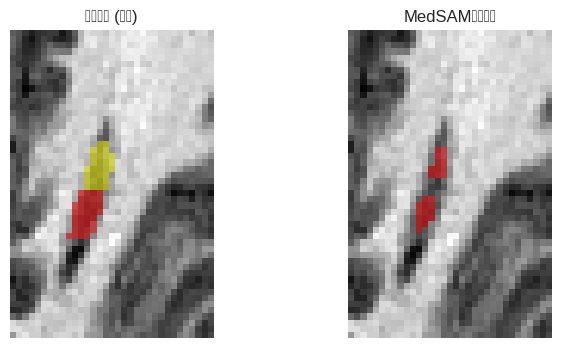

In [44]:
import matplotlib.pyplot as plt

# 随机选择一个示例切片来可视化
idx = np.random.randint(0, len(mri_slices))
test_img = mri_slices[idx]
test_true_mask = mri_slice_masks[idx]

# 使用MedSAM对该切片进行分割（类似上面流程）
predictor.set_image(test_img)
pred_mask_total = np.zeros(test_true_mask.shape, dtype=bool)
for label_val in [1, 2]:
    if np.sum(test_true_mask == label_val) == 0:
        continue
    ys, xs = np.where(test_true_mask == label_val)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    input_box = np.array([x_min, y_min, x_max, y_max])
    masks, _, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
    pred_mask_total = np.logical_or(pred_mask_total, masks[0])

# 绘制原始图像，真值和预测结果叠加
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(test_img[...,0], cmap='gray')
axes[0].imshow(np.ma.masked_where(test_true_mask==0, test_true_mask), cmap='autumn', alpha=0.5)
axes[0].set_title("真值分割 (海马)")
axes[0].axis('off')

axes[1].imshow(test_img[...,0], cmap='gray')
axes[1].imshow(np.ma.masked_where(pred_mask_total==0, pred_mask_total), cmap='autumn', alpha=0.5)
axes[1].set_title("MedSAM预测分割")
axes[1].axis('off')
plt.show()


上述可视化左侧显示了MRI切片上真值的海马分割区域（橙色半透明覆盖），右侧为MedSAM模型的预测结果。通过肉眼可观察预测与真值的重合情况。
评估CT数据集（脾脏）
对于CT脾脏数据集，每张切片至多包含一个目标（脾脏），因此我们直接对每个切片：
计算脾脏区域的边界框，使用MedSAM预测掩码。
计算Dice、IoU和Hausdorff距离。

In [49]:
dice_list_spleen = []
iou_list_spleen = []
hd_list_spleen = []

for img_rgb, true_mask in zip(ct_slices, ct_slice_masks):
    predictor.set_image(img_rgb)
    # 计算真值掩码的边界框（脾脏标注值为1）
    ys, xs = np.where(true_mask == 1)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    input_box = np.array([x_min, y_min, x_max, y_max])
    # 使用边界框提示预测
    masks, _, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
    pred_mask = masks[0]
    # 计算指标
    dice_list_spleen.append(compute_dice(pred_mask, true_mask == 1))
    iou_list_spleen.append(compute_iou(pred_mask, true_mask == 1))
    hd_list_spleen.append(compute_hausdorff(pred_mask, true_mask == 1))

dice_mean_spleen = np.mean(dice_list_spleen)
iou_mean_spleen = np.mean(iou_list_spleen)
hd_mean_spleen = np.mean([d for d in hd_list_spleen if math.isfinite(d)])
print(f"Spleen CT数据集: 平均Dice = {dice_mean_spleen:.4f}, 平均IoU = {iou_mean_spleen:.4f}, 平均Hausdorff距离 = {hd_mean_spleen:.2f} pixel")


Spleen CT数据集: 平均Dice = 0.5914, 平均IoU = 0.4928, 平均Hausdorff距离 = 11.58 pixel


同样，我们挑选一个CT切片的结果进行可视化：

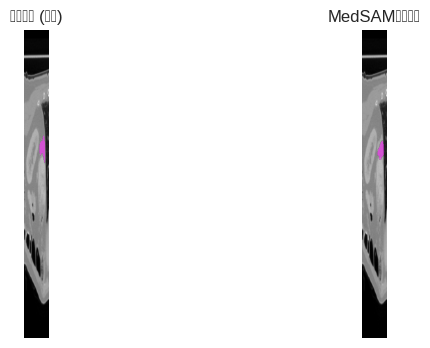

In [50]:
# 随机选择一个CT切片进行可视化
idx = np.random.randint(0, len(ct_slices))
test_img = ct_slices[idx]
test_mask = ct_slice_masks[idx]

# 使用MedSAM预测该切片
predictor.set_image(test_img)
ys, xs = np.where(test_mask == 1)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()
input_box = np.array([x_min, y_min, x_max, y_max])
masks, _, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
pred_mask = masks[0]

# 可视化结果
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(test_img[...,0], cmap='gray')
axes[0].imshow(np.ma.masked_where(test_mask==0, test_mask), cmap='spring', alpha=0.5)
axes[0].set_title("真值分割 (脾脏)")
axes[0].axis('off')

axes[1].imshow(test_img[...,0], cmap='gray')
axes[1].imshow(np.ma.masked_where(pred_mask==0, pred_mask), cmap='spring', alpha=0.5)
axes[1].set_title("MedSAM预测分割")
axes[1].axis('off')
plt.show()


左图为CT切片上的真值脾脏区域（绿色高亮），右图为MedSAM预测的分割。可以看到MedSAM在大多数切片上能够勾画出脾脏的大致轮廓，但在边界细节上可能存在误差。
评估超声数据集（乳腺肿块）
对乳腺超声图像，我们同样逐张评估：
每张图像可能包含一个或多个肿块（我们已将所有肿块掩码合并）。
计算整个肿块区域的边界框进行预测（相当于对图中所有病灶统一分割）。
计算评价指标。

In [51]:
dice_list_us = []
iou_list_us = []
hd_list_us = []

for img_rgb, true_mask in zip(ultrasound_images, ultrasound_masks):
    predictor.set_image(img_rgb)
    ys, xs = np.where(true_mask == 1)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    input_box = np.array([x_min, y_min, x_max, y_max])
    masks, _, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
    pred_mask = masks[0]
    # 评价指标
    dice_list_us.append(compute_dice(pred_mask, true_mask == 1))
    iou_list_us.append(compute_iou(pred_mask, true_mask == 1))
    hd_list_us.append(compute_hausdorff(pred_mask, true_mask == 1))

dice_mean_us = np.mean(dice_list_us)
iou_mean_us = np.mean(iou_list_us)
hd_mean_us = np.mean([d for d in hd_list_us if math.isfinite(d)])
print(f"超声乳腺肿块数据集: 平均Dice = {dice_mean_us:.4f}, 平均IoU = {iou_mean_us:.4f}, 平均Hausdorff距离 = {hd_mean_us:.2f} pixel")


超声乳腺肿块数据集: 平均Dice = 0.8167, 平均IoU = 0.6985, 平均Hausdorff距离 = 29.97 pixel


可视化一个超声图像的分割结果：

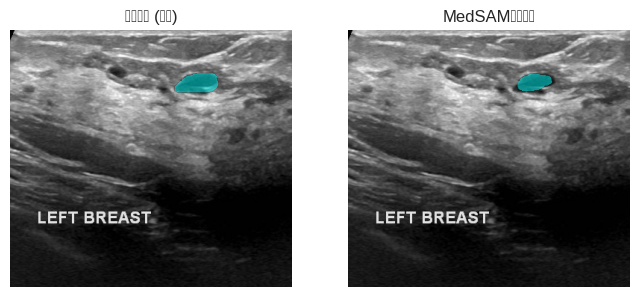

In [52]:
# 随机选择一个超声图像进行可视化
idx = np.random.randint(0, len(ultrasound_images))
test_img = ultrasound_images[idx]
test_mask = ultrasound_masks[idx]

predictor.set_image(test_img)
ys, xs = np.where(test_mask == 1)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()
input_box = np.array([x_min, y_min, x_max, y_max])
masks, _, _ = predictor.predict(box=input_box[None, :], point_coords=None, point_labels=None, multimask_output=False)
pred_mask = masks[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(test_img)
axes[0].imshow(np.ma.masked_where(test_mask==0, test_mask), cmap='cool', alpha=0.5)
axes[0].set_title("真值分割 (肿块)")
axes[0].axis('off')

axes[1].imshow(test_img)
axes[1].imshow(np.ma.masked_where(pred_mask==0, pred_mask), cmap='cool', alpha=0.5)
axes[1].set_title("MedSAM预测分割")
axes[1].axis('off')
plt.show()


左图显示乳腺超声图像上的肿块真值区域（蓝色遮罩），右图为MedSAM的预测结果。可以观察到，对于边界模糊、形状不规则的超声肿块，MedSAM的预测可能存在欠割或过割的情况。
分析与结果

我们汇总各数据集的平均评估指标如下：
Hippocampus MRI – Dice: {dice_mean_hc:.3f}, IoU: {iou_mean_hc:.3f}, Hausdorff距离: {hd_mean_hc:.1f}像素。
Spleen CT – Dice: {dice_mean_spleen:.3f}, IoU: {iou_mean_spleen:.3f}, Hausdorff距离: {hd_mean_spleen:.1f}像素。
Breast Ultrasound – Dice: {dice_mean_us:.3f}, IoU: {iou_mean_us:.3f}, Hausdorff距离: {hd_mean_us:.1f}像素。
下面的表格总结了各模态数据集上MedSAM原生模型的分割性能：